# 1. Modify the part from napari-assistant to process images and get the labeled image

In [1]:
from skimage.io import imread
import stackview
import napari_segment_blobs_and_things_with_membranes as nsbatwm  # version 0.3.12
import napari_simpleitk_image_processing as nsitk  # version 0.4.9
import pyclesperanto as cle  # version 0.14.2
import napari
viewer = napari.Viewer()

C:\Users\achun\.conda\envs\EABIAS_TP_2026\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Loading 'Extract_slice'

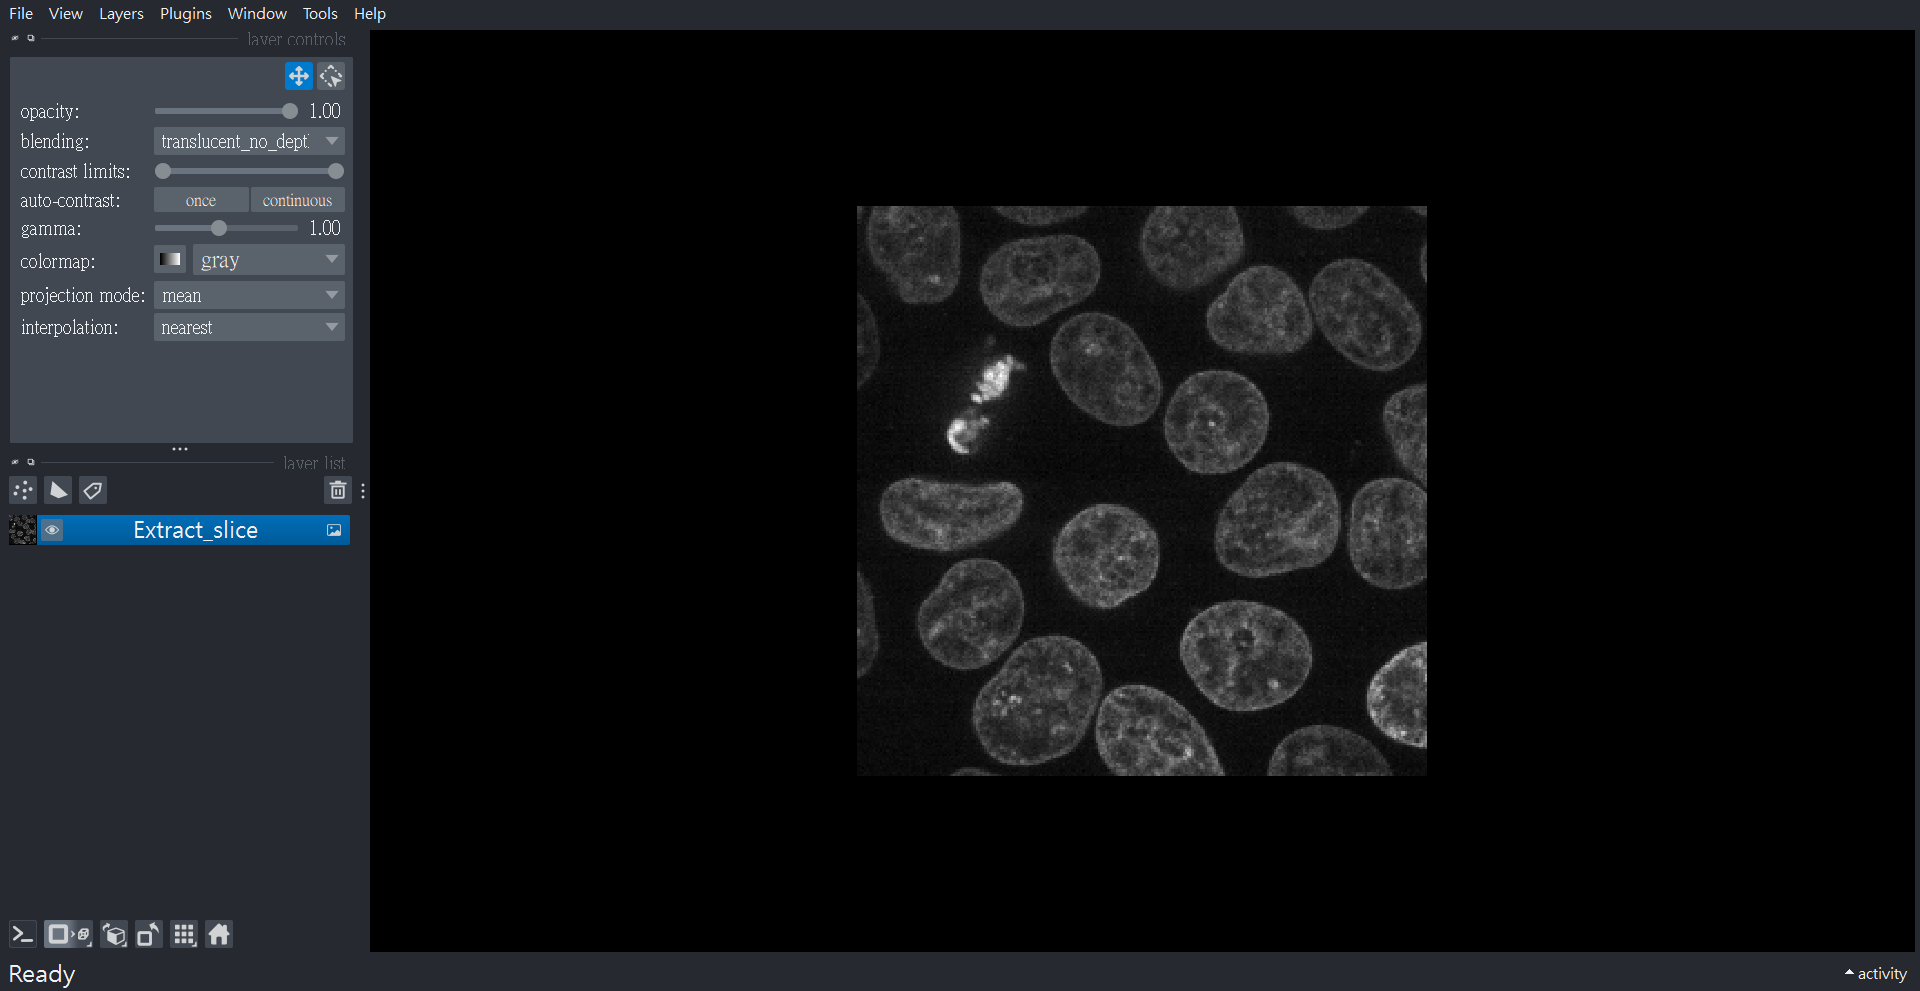

In [2]:
image0_Es = imread("C:/Users/achun/EABIAS_TP_2026/data/Extract_slice.tif")
viewer.add_image(image0_Es, name='Extract_slice')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## gaussian blur

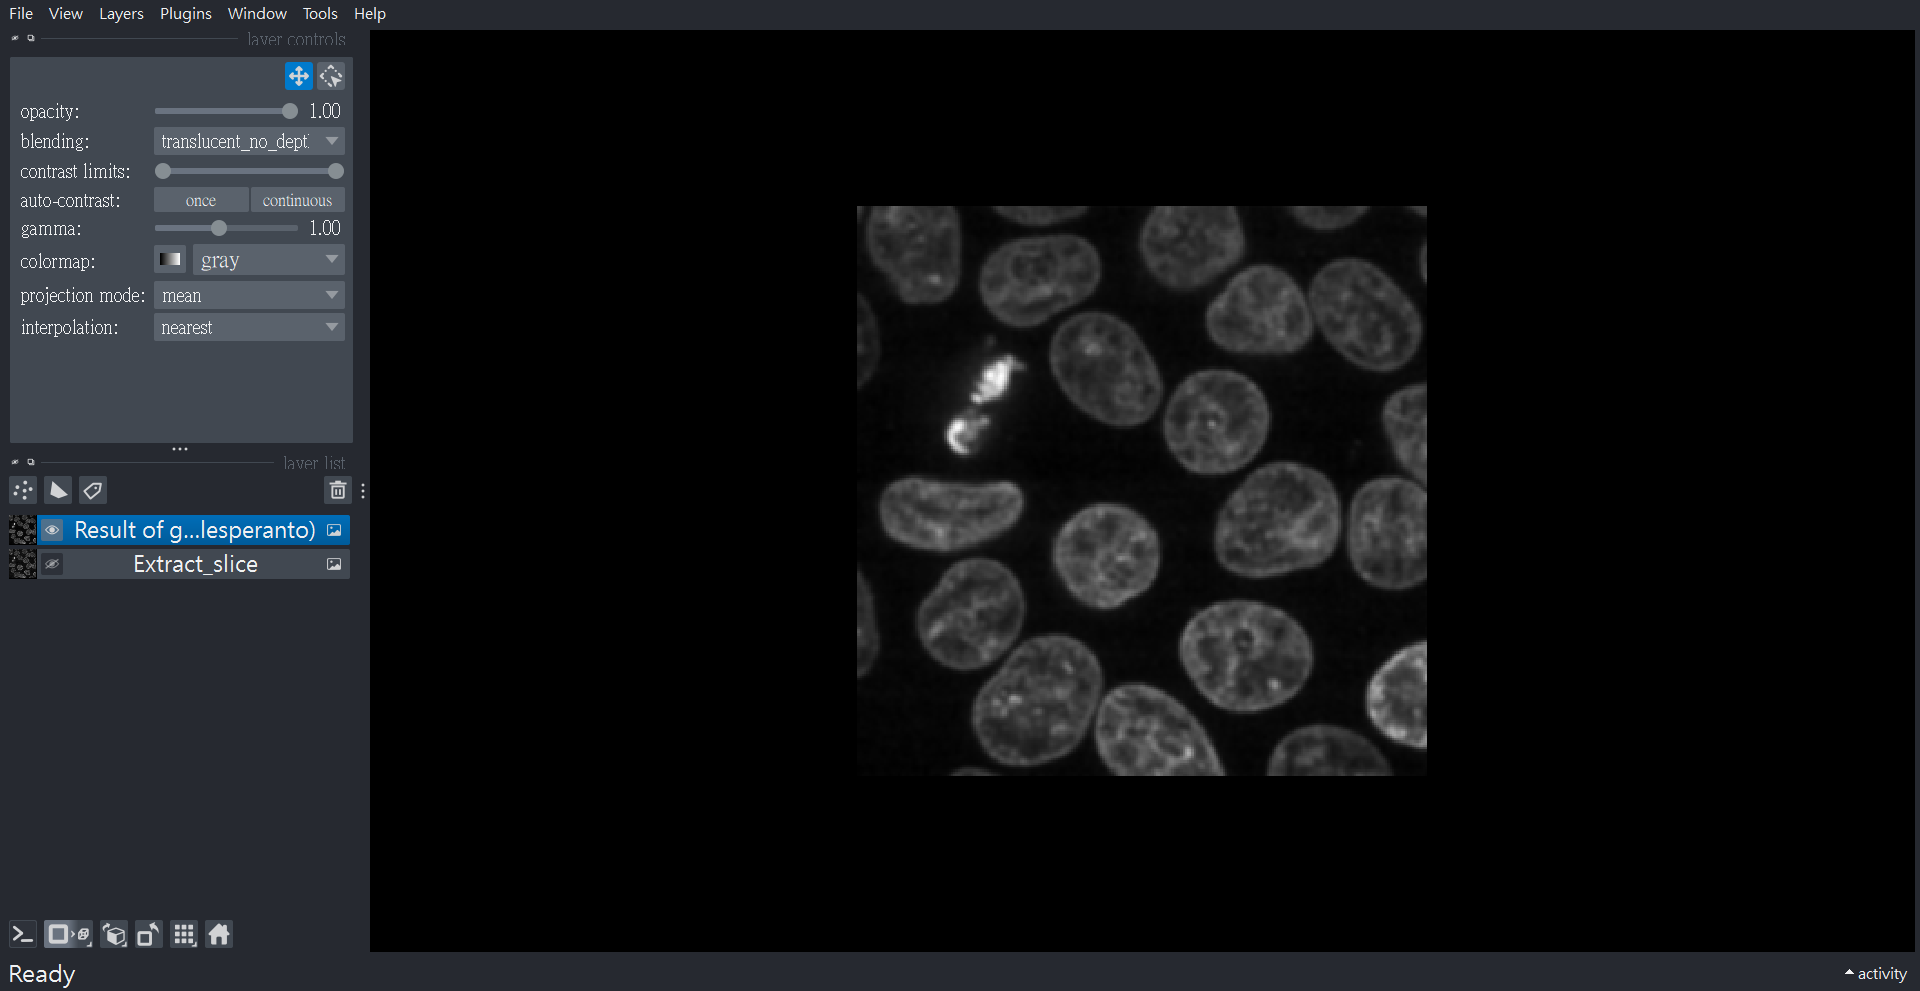

In [3]:
image1_gb = cle.gaussian_blur(image0_Es, None, 1.0, 1.0, 0)
viewer.add_image(image1_gb, name='Result of gaussian_blur (pyclesperanto)')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## threshold otsu

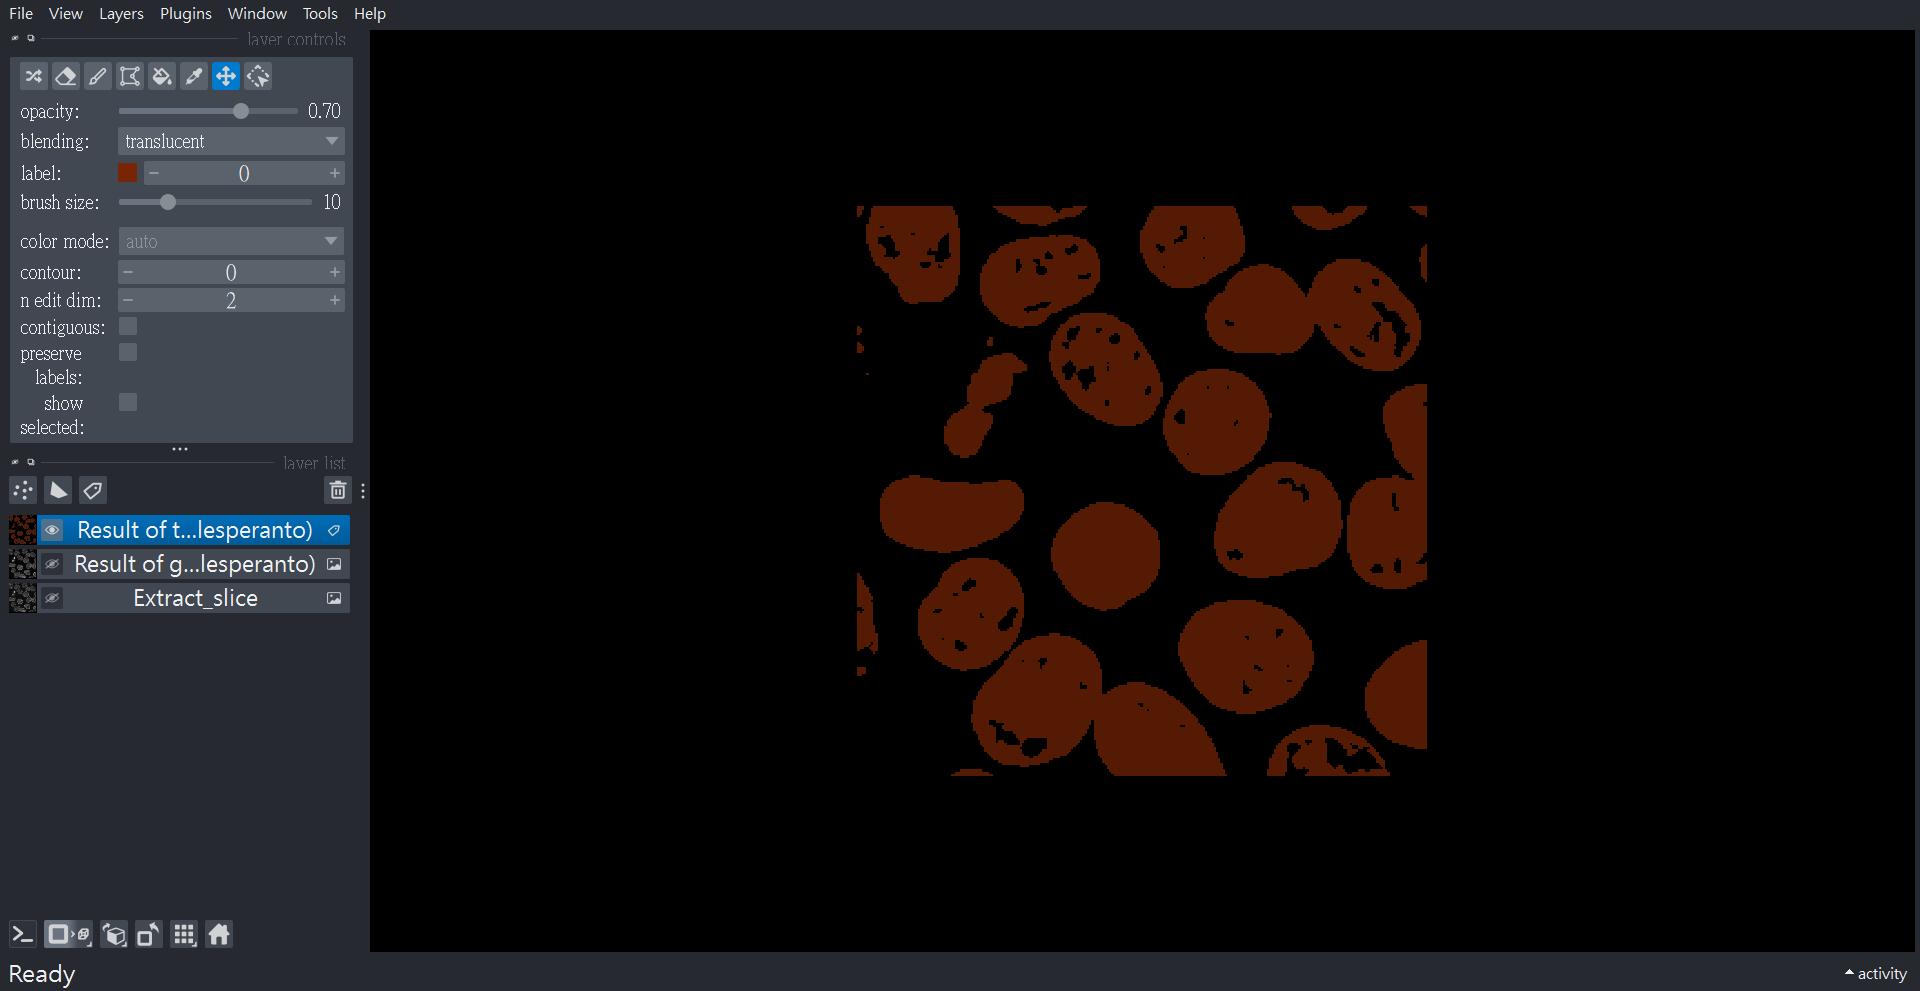

In [4]:
image2_to = cle.threshold_otsu(image1_gb)
viewer.add_labels(image2_to, name='Result of threshold_otsu (pyclesperanto)')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## binary fill holes

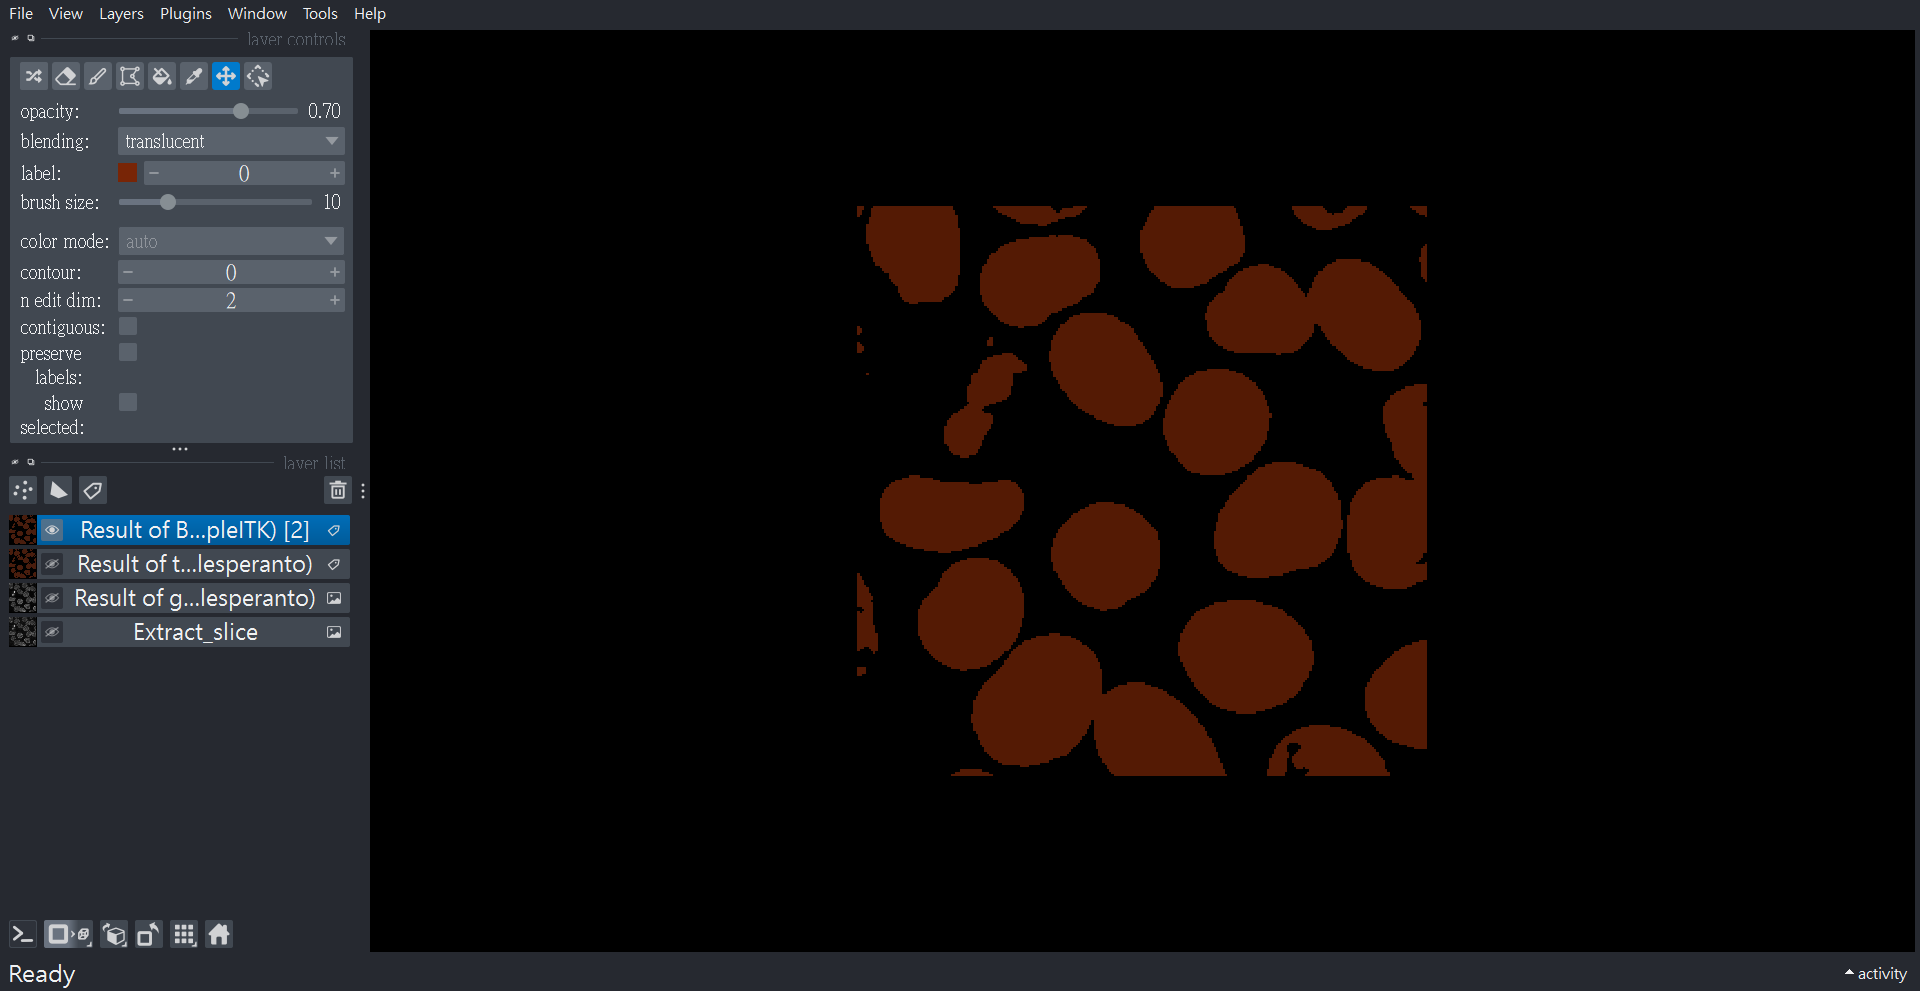

In [5]:
image3_B = nsitk.binary_fill_holes(image2_to)
viewer.add_labels(
    image3_B, name='Result of Binary fill holes (n-SimpleITK) [2]')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## split touching objects

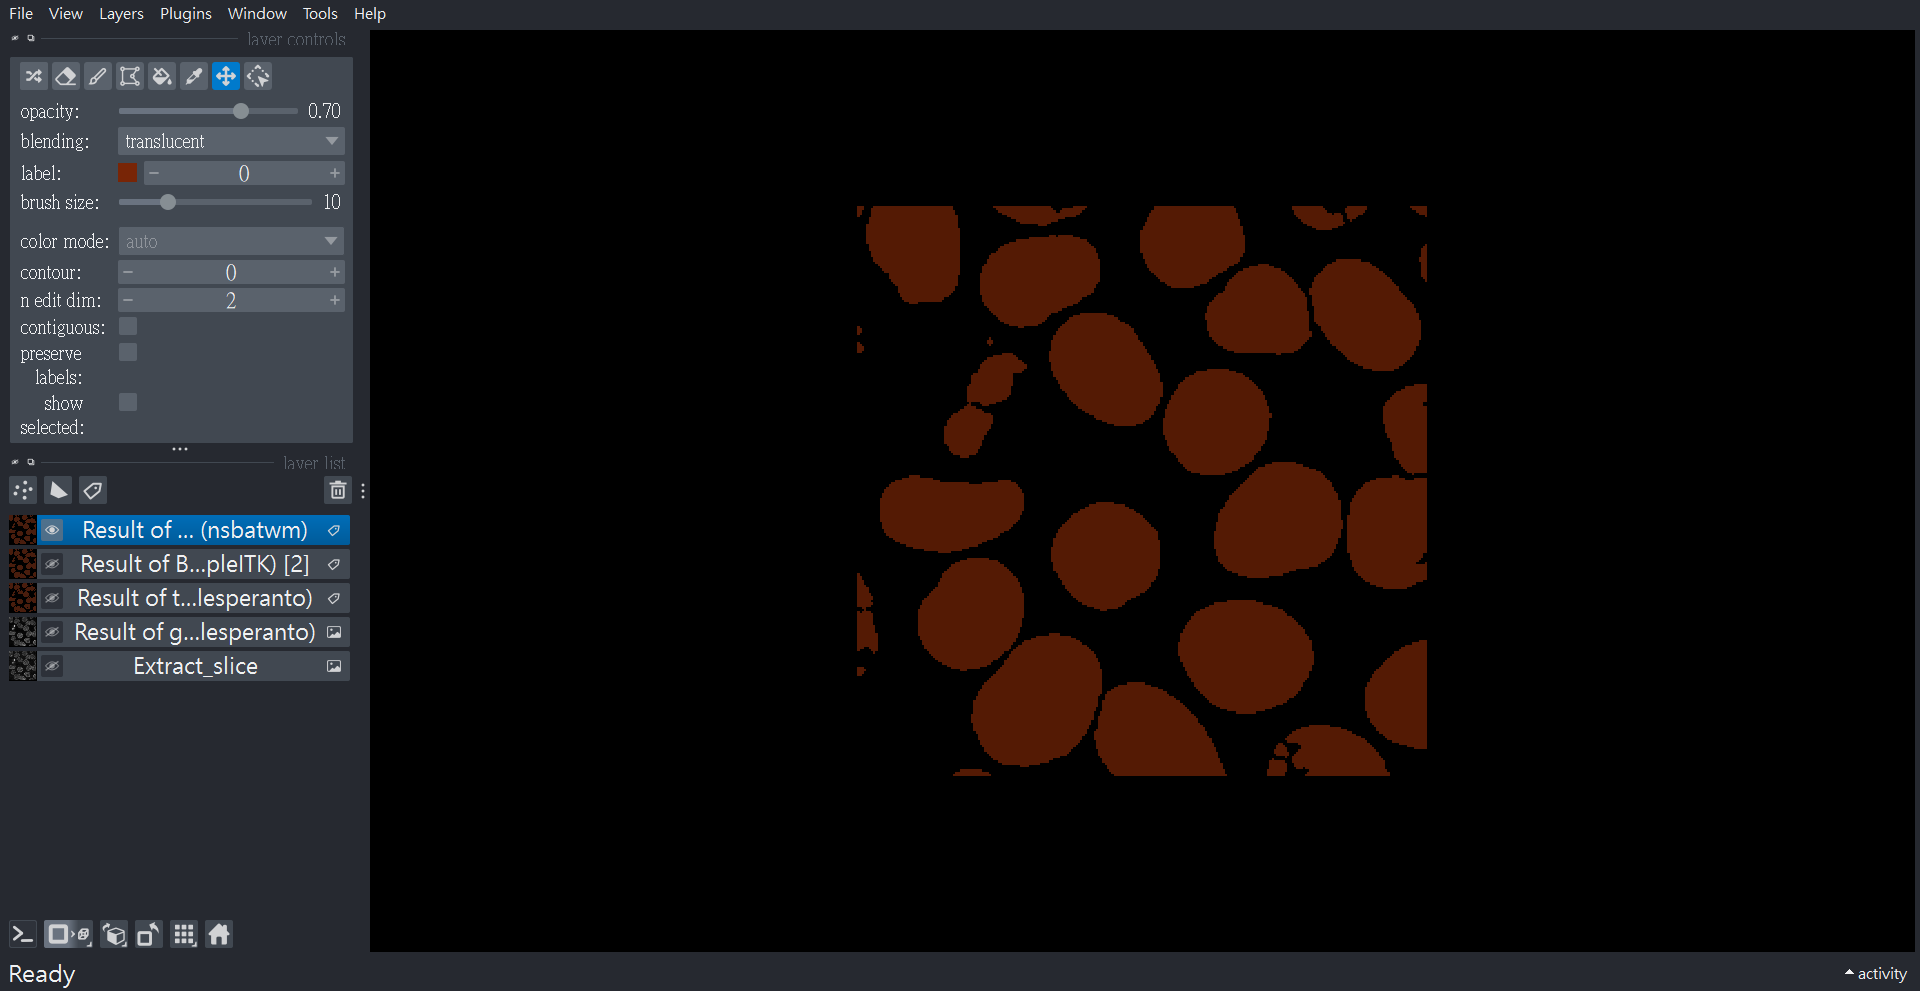

In [6]:
image4_S = nsbatwm.split_touching_objects(image3_B, 6.0)
viewer.add_labels(image4_S, name='Result of Split touching objects (nsbatwm)')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## connected component labeling

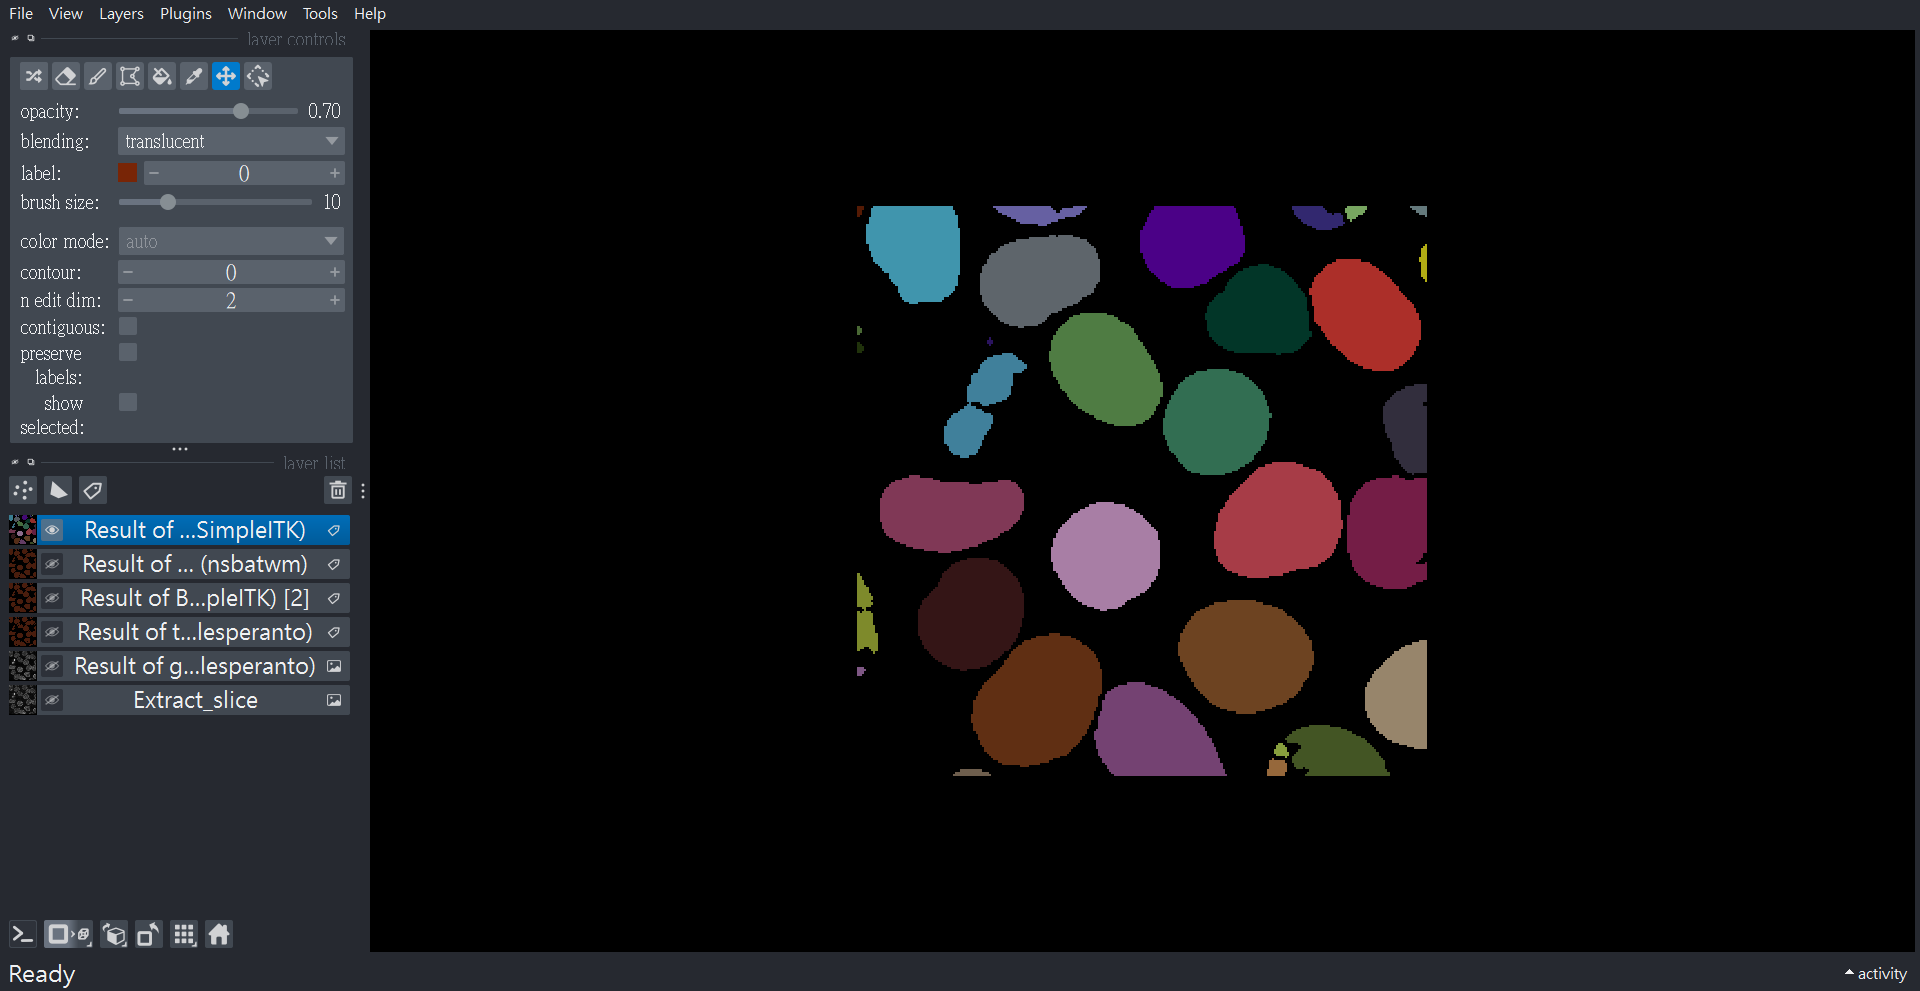

In [7]:
image5_C = nsitk.connected_component_labeling(image4_S)
viewer.add_labels(
    image5_C, name='Result of Connected component labeling (n-SimpleITK)')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## remove small labels

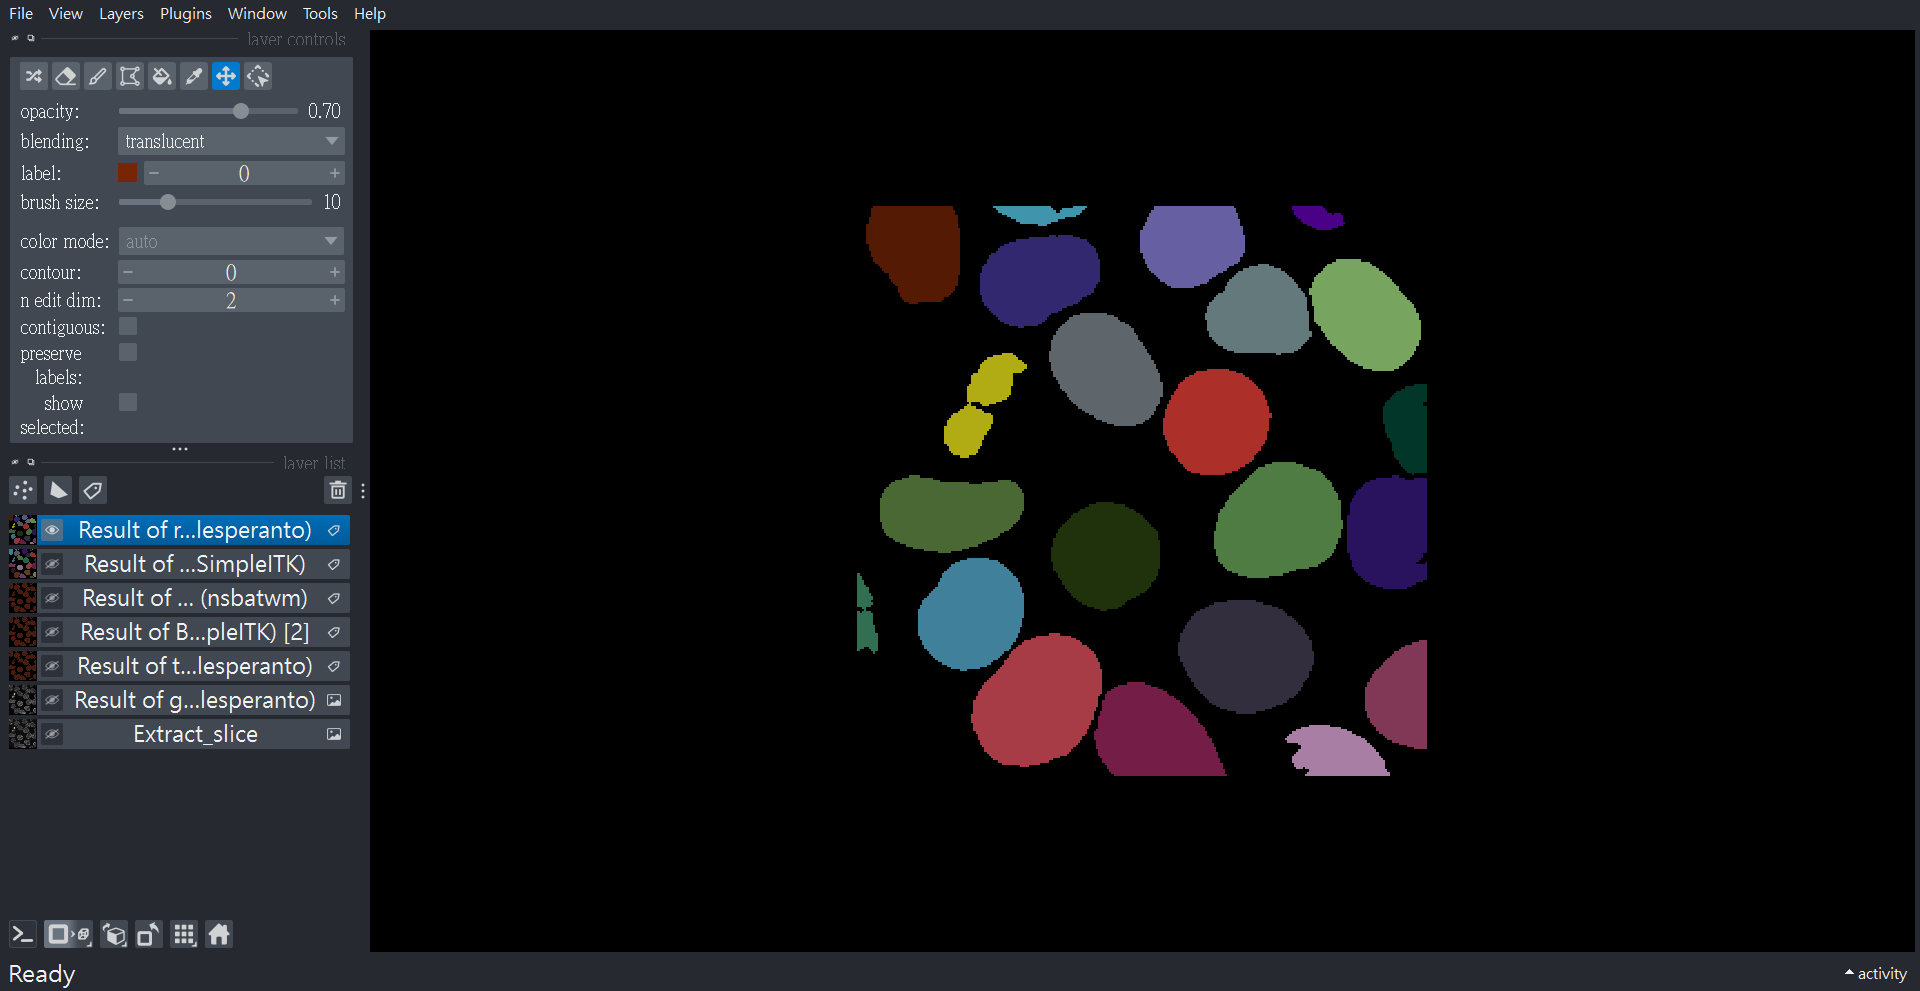

In [8]:
image6_rsl = cle.remove_small_labels(image5_C, None, 100)
viewer.add_labels(
    image6_rsl, name='Result of remove_small_labels (pyclesperanto)')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

## exclude labels on edges

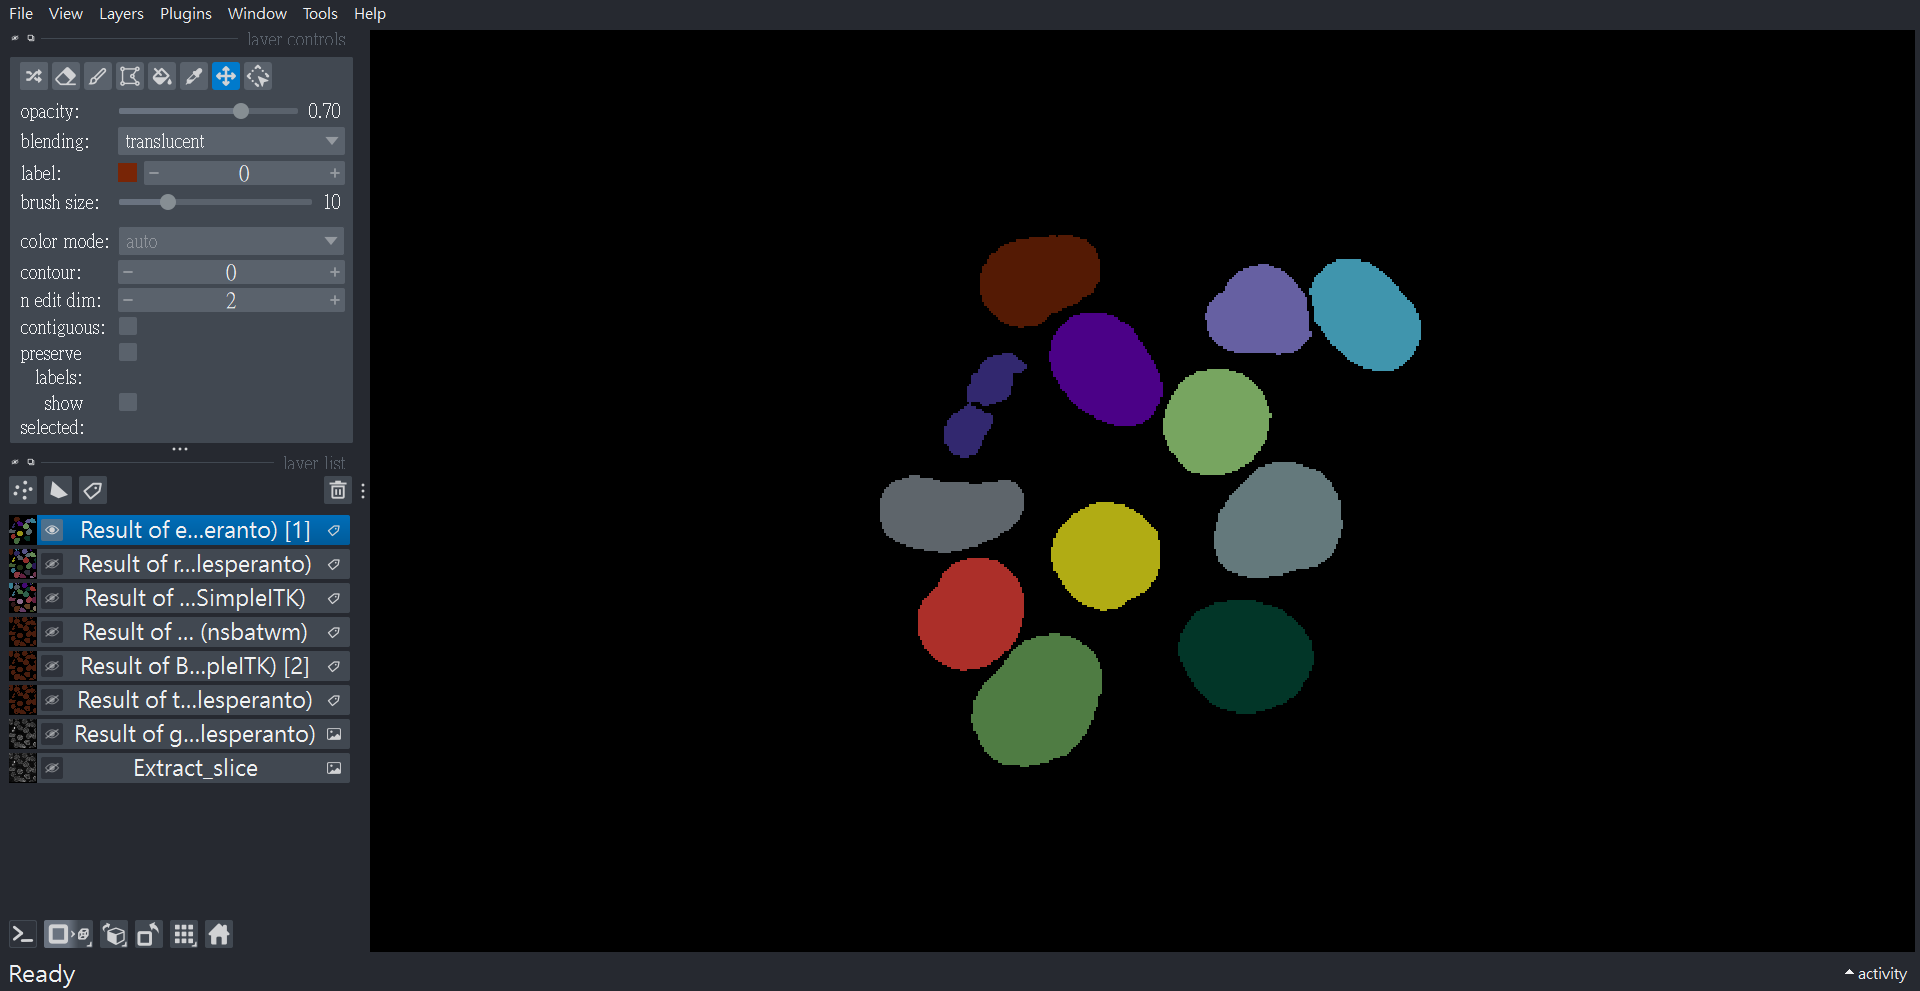

In [9]:
image7_eloe = cle.exclude_labels_on_edges(image6_rsl, None, True, True, True)
viewer.add_labels(
    image7_eloe, name='Result of exclude_labels_on_edges (pyclesperanto) [1]')
for layer in viewer.layers[:-1]:
    layer.visible = False
napari.utils.nbscreenshot(viewer)

# 2. Use Numpy to get the measurement

In [12]:
from skimage.io import imshow, imread
import pandas as pd
import numpy as np
from skimage.measure import regionprops_table

## Define the intensity image and labeled image

C:\Users\achun\AppData\Local\Temp\ipykernel_24380\942079764.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image0_Es)


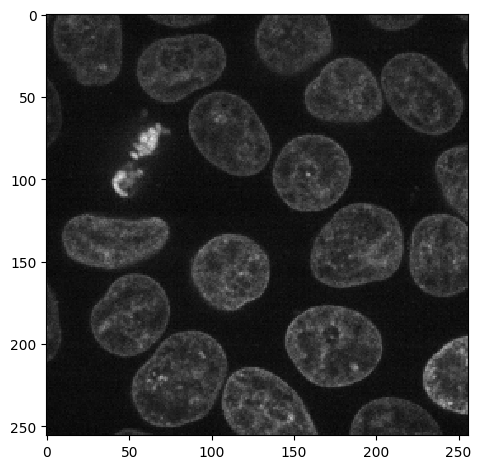

In [13]:
image = image0_Es
labels = image7_eloe
imshow(image0_Es)

## Check the data type

In [14]:
print(type(labels))
print(type(image))

<class 'pyclesperanto._pyclesperanto._Array'>
<class 'numpy.ndarray'>


## Convert to numpy array

In [17]:
labels_np = cle.pull(labels)
image_np = cle.pull(image)
print(type(labels_np))
print(type(image_np))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [18]:
table = regionprops_table(
    labels_np,
    intensity_image=image_np,
    properties=[
        'area',
        'minor_axis_length',
        'major_axis_length',
        'eccentricity',
        'feret_diameter_max',
        'intensity_mean'
    ]
)
data_frame = pd.DataFrame(table)
data_frame

,area,minor_axis_length,major_axis_length,eccentricity,feret_diameter_max,intensity_mean
0,1697.0,38.332822,56.894319,0.738955,56.859476,12923.918680
1,1801.0,40.103522,57.257249,0.713741,57.140179,12213.287063
2,1481.0,40.656598,47.216922,0.508504,49.244289,14435.270763
3,1899.0,41.787375,57.972429,0.693128,58.249464,12403.741969
4,771.0,19.181610,58.749130,0.945197,53.000000,24282.211414
5,1811.0,46.869744,49.219336,0.305279,50.606324,14269.220320
6,2339.0,49.383122,60.762212,0.582644,62.128898,14649.041898
7,1761.0,33.781060,68.388312,0.869485,66.490601,16582.440091
8,1813.0,47.406695,48.765686,0.234433,50.695167,16929.717595
9,1855.0,44.744036,52.904722,0.533583,53.488316,13553.976280


## Learn more about the regionprops

In [19]:
from skimage.measure import regionprops

help(regionprops)

Help on function regionprops in module skimage.measure._regionprops:

regionprops(label_image, intensity_image=None, cache=True, *, extra_properties=None, spacing=None, offset=None)
    Measure properties of labeled image regions.
    
    Parameters
    ----------
    label_image : (M, N[, P]) ndarray
        Labeled input image. Labels with value 0 are ignored.
    
        .. versionchanged:: 0.14.1
            Previously, ``label_image`` was processed by ``numpy.squeeze`` and
            so any number of singleton dimensions was allowed. This resulted in
            inconsistent handling of images with singleton dimensions. To
            recover the old behaviour, use
            ``regionprops(np.squeeze(label_image), ...)``.
    intensity_image : (M, N[, P][, C]) ndarray, optional
        Intensity (i.e., input) image with same size as labeled image, plus
        optionally an extra dimension for multichannel data. Currently,
        this extra channel dimension, if present, must